In [1]:
import sys
!{sys.executable} -m pip install -q torch matplotlib numpy scikit-learn

WORD SIMILARITY ANALYSIS
Word 1   Word 2  Cosine Similarity
  king    queen             0.0182
  king    apple            -0.4323
 apple   orange             0.2948
prince princess             0.3833
 royal    young             0.1476


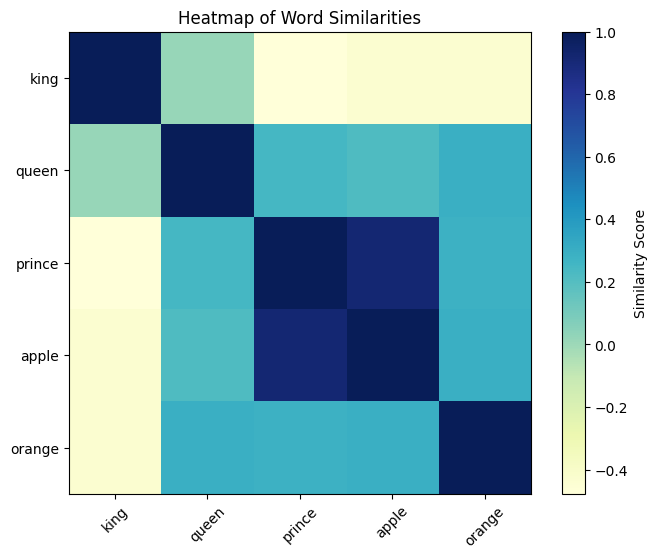

In [2]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

# --- 1. Dataset & Training (Quick Setup) ---
corpus = """
king is a royal man
queen is a royal woman
prince is a young royal man
princess is a young royal woman
apple is a sweet fruit
orange is a citrus fruit
"""
tokens = corpus.lower().split()
vocab = sorted(list(set(tokens)))
word_to_ix = {w: i for i, w in enumerate(vocab)}
ix_to_word = {i: w for i, w in enumerate(vocab)}
vocab_size = len(vocab)

# Skip-gram data generation
data = []
for i in range(1, len(tokens) - 1):
    data.append((tokens[i], tokens[i-1]))
    data.append((tokens[i], tokens[i+1]))

# Model definition
class Word2Vec(nn.Module):
    def __init__(self, vocab_size, embed_dim):
        super().__init__()
        self.embeddings = nn.Embedding(vocab_size, embed_dim)
        self.linear = nn.Linear(embed_dim, vocab_size)
    def forward(self, x):
        return self.linear(self.embeddings(x))

model = Word2Vec(vocab_size, 10)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

# Quick training loop
for epoch in range(200):
    for target, context in data:
        optimizer.zero_grad()
        loss = criterion(model(torch.tensor([word_to_ix[target]])), torch.tensor([word_to_ix[context]]))
        loss.backward()
        optimizer.step()

# --- 2. Similarity Analysis ---
# Extract learned embeddings
vectors = model.embeddings.weight.data.numpy()

def get_similarity(word1, word2):
    if word1 not in word_to_ix or word2 not in word_to_ix:
        return 0.0
    v1 = vectors[word_to_ix[word1]].reshape(1, -1)
    v2 = vectors[word_to_ix[word2]].reshape(1, -1)
    return cosine_similarity(v1, v2)[0][0]

# --- 3. Results & Visualization ---
test_pairs = [
    ("king", "queen"), 
    ("king", "apple"), 
    ("apple", "orange"), 
    ("prince", "princess"),
    ("royal", "young")
]

sim_results = []
for w1, w2 in test_pairs:
    score = get_similarity(w1, w2)
    sim_results.append({"Word 1": w1, "Word 2": w2, "Cosine Similarity": round(score, 4)})

df = pd.DataFrame(sim_results)

print("="*50)
print("WORD SIMILARITY ANALYSIS")
print("="*50)
print(df.to_string(index=False))

# Visualizing Similarity Matrix for a subset
subset = ["king", "queen", "prince", "apple", "orange"]
matrix = np.zeros((len(subset), len(subset)))

for i, w1 in enumerate(subset):
    for j, w2 in enumerate(subset):
        matrix[i, j] = get_similarity(w1, w2)

plt.figure(figsize=(8, 6))
plt.imshow(matrix, cmap='YlGnBu')
plt.colorbar(label='Similarity Score')
plt.xticks(range(len(subset)), subset, rotation=45)
plt.yticks(range(len(subset)), subset)
plt.title("Heatmap of Word Similarities")
plt.show()